# Volatility Surface CAE Project

## 0. Real Data Pulled from WRDS

In [ ]:
import pandas as pd
import numpy as np

_reader = pd.read_sas("data/options.sas7bdat.gz", encoding="utf-8", chunksize=1_000_000)
raw_options = pd.concat(list(_reader), ignore_index=True)
del _reader  # for RAM

n_rows = len(raw_options)
priced = raw_options[~raw_options["impl_volatility"].isna()]
n_priced = len(priced)

strikes_per_group = priced.groupby(["secid", "date", "days"])["strike_price"].nunique()

real_data_summary = pd.DataFrame(
    {
        "metric": [
            "Total quote-rows pulled",
            "Rows with a non-null implied vol",
            "Unique securities (secid)",
            "Date range",
            "Trading dates covered",
            'Distinct tenors ("days" field)',
            "(security, date, tenor) groups",
            "Groups with exactly 1 distinct strike",
        ],
        "value": [
            f"{n_rows:,}",
            f"{n_priced:,} ({n_priced/n_rows:.1%})",
            f"{priced['secid'].nunique():,}",
            f"{priced['date'].min().date()} to {priced['date'].max().date()}",
            f"{priced['date'].nunique():,}",
            f"{priced['days'].nunique()}  {sorted(priced['days'].dropna().unique().astype(int).tolist())}",
            f"{len(strikes_per_group):,}",
            f"{(strikes_per_group == 1).mean():.3%}",
        ],
    }
)
display(real_data_summary)

,metric,value
0,Total quote-rows pulled,"21,915,578"
1,Rows with a non-null implied vol,"20,609,074 (94.0%)"
2,Unique securities (secid),500
3,Date range,2015-08-31 to 2025-08-29
4,Trading dates covered,"2,515"
5,"Distinct tenors (""days"" field)","11 [10, 30, 60, 91, 122, 152, 182, 273, 365, ..."
6,"(security, date, tenor) groups","10,304,537"
7,Groups with exactly 1 distinct strike,99.996%


In [24]:
# no longer needed; everything below uses the synthetic pipeline
del raw_options, priced, strikes_per_group

## 1. Setup

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.interpolate import CubicSpline

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

RNG_SEED = 360
rng = np.random.default_rng(RNG_SEED)
torch.manual_seed(RNG_SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cpu


## 2. Data Processing

### 2.1 Target grid

In [26]:
MONEYNESS_GRID = np.linspace(0.8, 1.2, 41)
MATURITY_DAYS = np.arange(1, 13) * 30
MATURITY_YEARS = MATURITY_DAYS / 365.0

N_MATURITY = len(MATURITY_DAYS)
N_MONEYNESS = len(MONEYNESS_GRID)
LOG_MONEYNESS = np.log(MONEYNESS_GRID)  # SVI is parameterized in k = ln(K/S)

print(f"grid shape: ({N_MATURITY}, {N_MONEYNESS}, 1)")
print(f"maturities (days): {MATURITY_DAYS}")
print(
    f"moneyness range: [{MONEYNESS_GRID[0]:.3f}, {MONEYNESS_GRID[-1]:.3f}], step={MONEYNESS_GRID[1]-MONEYNESS_GRID[0]:.4f}"
)

grid shape: (12, 41, 1)
maturities (days): [ 30  60  90 120 150 180 210 240 270 300 330 360]
moneyness range: [0.800, 1.200], step=0.0100


### 2.2 Synthetic ground-truth surfaces (SVI)

Each surface gets a smooth SVI parameter path across tenors, calendar-arbitrage-free by
construction. Used only for evaluation.

In [ ]:
def svi_total_variance(k, a, b, rho, m, sigma):
    """Raw SVI total-variance parameterization (Gatheral, 2004)."""
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma**2))


def sample_svi_surface_params(rng):
    """Smooth, roughly arbitrage-free SVI parameter path across the 12 tenors."""
    atm_var_1m = rng.uniform(0.02, 0.06)
    var_slope = rng.uniform(
        0.01, 0.05
    )  # total variance increases with maturity to ensure no arbitrage

    b = rng.uniform(0.05, 0.25)
    rho = rng.uniform(-0.6, -0.1)
    m = rng.uniform(-0.05, 0.05)
    sigma = rng.uniform(0.05, 0.2)

    params = []
    for tau in MATURITY_YEARS:
        b = np.clip(b + rng.normal(0, 0.01), 0.02, 0.4)
        rho = np.clip(rho + rng.normal(0, 0.02), -0.9, 0.9)
        m = np.clip(m + rng.normal(0, 0.005), -0.15, 0.15)
        sigma = np.clip(sigma + rng.normal(0, 0.01), 0.02, 0.4)
        total_var_atm = atm_var_1m + var_slope * tau
        a = total_var_atm - b * sigma
        params.append(dict(a=a, b=b, rho=rho, m=m, sigma=sigma))
    return params


def build_clean_surface(params):
    surface = np.zeros((N_MATURITY, N_MONEYNESS))
    for i, (p, tau) in enumerate(zip(params, MATURITY_YEARS)):
        w = np.clip(svi_total_variance(LOG_MONEYNESS, **p), 1e-6, None)
        surface[i] = np.sqrt(w / tau)
    return surface


example_params = sample_svi_surface_params(rng)
example_surface = build_clean_surface(example_params)
print(
    f"example clean surface shape: {example_surface.shape}, IV range: [{example_surface.min():.3f}, {example_surface.max():.3f}]"
)

example clean surface shape: (12, 41), IV range: [0.321, 1.151]


### 2.3 Simulated noisy/sparse market quotes -> interpolated input grid

For each tenor, sample a few quoted moneyness points (always including both edges), add
noise, then interpolate back onto `MONEYNESS_GRID`.

In [28]:
def simulate_noisy_input(
    clean_surface, rng, min_quotes=6, max_quotes=14, noise_std=0.01, method="cubic"
):
    noisy = np.full_like(clean_surface, np.nan)
    for i in range(N_MATURITY):
        n_quotes = rng.integers(min_quotes, max_quotes + 1)
        interior = rng.choice(
            np.arange(1, N_MONEYNESS - 1), size=n_quotes - 2, replace=False
        )
        idx = np.sort(np.concatenate([[0], interior, [N_MONEYNESS - 1]]))
        x = MONEYNESS_GRID[idx]
        y = clean_surface[i, idx] + rng.normal(0, noise_std, size=len(idx))
        y = np.clip(y, 1e-4, None)  # implied vol is non-negative
        if method == "linear":
            noisy[i] = np.interp(MONEYNESS_GRID, x, y)
        elif method == "cubic":
            noisy[i] = CubicSpline(x, y, extrapolate=False)(MONEYNESS_GRID)
        else:
            raise ValueError(f"unknown method {method!r}")
    return noisy


INTERP_METHOD = "cubic"
example_noisy = simulate_noisy_input(example_surface, rng, method=INTERP_METHOD)
print(
    f"NaN cells in example noisy grid: {np.isnan(example_noisy).sum()} / {example_noisy.size}"
)

NaN cells in example noisy grid: 0 / 492


### 2.4 Build the full synthetic dataset

In [29]:
N_SAMPLES = 1500

X_clean = np.zeros((N_SAMPLES, N_MATURITY, N_MONEYNESS), dtype=np.float32)
X_noisy = np.zeros((N_SAMPLES, N_MATURITY, N_MONEYNESS), dtype=np.float32)

for n in range(N_SAMPLES):
    params = sample_svi_surface_params(rng)
    clean = build_clean_surface(params)
    noisy = simulate_noisy_input(clean, rng, method=INTERP_METHOD)
    X_clean[n] = clean
    X_noisy[n] = noisy

X_clean = X_clean[..., None]
X_noisy = X_noisy[..., None]

print(f"X_clean.shape={X_clean.shape}")
print(f"X_noisy.shape={X_noisy.shape}")
print(f"NaN in X_noisy: {np.isnan(X_noisy).sum()}")
print(f"X_clean IV stats:\n{pd.Series(X_clean.ravel()).describe()}")
print(f"\nX_noisy IV stats:\n{pd.Series(X_noisy.ravel()).describe()}")

X_clean.shape=(1500, 12, 41, 1)
X_noisy.shape=(1500, 12, 41, 1)
NaN in X_noisy: 0
X_clean IV stats:
count    738000.000000
mean          0.394686
std           0.151210
min           0.168000
25%           0.295532
50%           0.345753
75%           0.441646
max           1.313994
dtype: float64

X_noisy IV stats:
count    738000.000000
mean          0.394754
std           0.162979
min          -2.505098
25%           0.294137
50%           0.347592
75%           0.445487
max           4.318537
dtype: float64


### 2.5 Example training sample

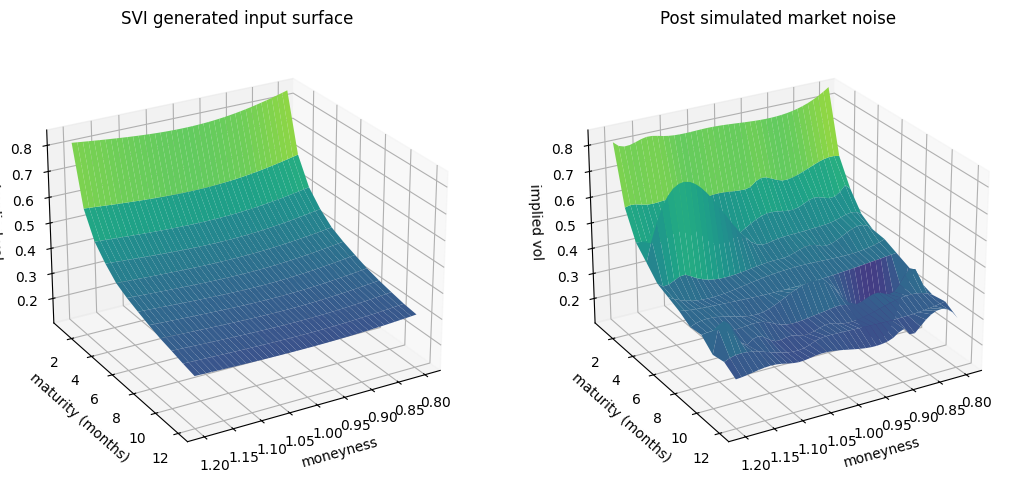

In [45]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(11, 5))
titles_3d = ["SVI generated input surface", "Post simulated market noise"]
data_3d = [X_clean[0, :, :, 0], X_noisy[0, :, :, 0]]
vmin = min(X_clean[0, :, :, 0].min(), X_noisy[0, :, :, 0].min())
vmax = max(X_clean[0, :, :, 0].max(), X_noisy[0, :, :, 0].max())
MM, TT = np.meshgrid(MONEYNESS_GRID, np.arange(1, N_MATURITY + 1))

for i, (title, d) in enumerate(zip(titles_3d, data_3d)):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.plot_surface(
        MM, TT, d, cmap="viridis", vmin=vmin, vmax=vmax, linewidth=0, antialiased=True
    )
    ax.set_title(title)
    ax.set_xlabel("moneyness")
    ax.set_ylabel("maturity (months)")
    ax.set_zlabel("implied vol")
    ax.set_zlim(vmin, vmax)
    ax.view_init(elev=25, azim=60)

plt.tight_layout()
plt.savefig("documents/ProgressReport/figures/synthetic_sample.png", dpi=200)
plt.show()

### 2.6 Train / validation / test split

70/15/15 split. Final testing (once real data is available) will split by
tickers.

In [31]:
X_noisy_t = torch.from_numpy(X_noisy).permute(0, 3, 1, 2)
X_clean_t = torch.from_numpy(X_clean).permute(0, 3, 1, 2)

dataset = TensorDataset(X_noisy_t, X_clean_t)

n_train = int(0.7 * N_SAMPLES)
n_val = int(0.15 * N_SAMPLES)
n_test = N_SAMPLES - n_train - n_val
train_ds, val_ds, test_ds = random_split(
    dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(RNG_SEED)
)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

# same fixed subset used for both baseline and CAE evaluation
EVAL_INDICES = sorted(test_ds.indices)[:100]
print(f"evaluation subset size: {len(EVAL_INDICES)}")

train=1050  val=225  test=225
evaluation subset size: 100


## 3. Baseline Model: SVI

Per-tenor SVI fit via least squares, with bounds enforcing basic no-arbitrage.

In [32]:
def fit_svi_tenor(k, w_obs):
    def resid(theta):
        a, b, rho, m, sigma = theta
        return svi_total_variance(k, a, b, rho, m, sigma) - w_obs

    theta0 = [max(w_obs.mean(), 1e-4), 0.1, -0.3, 0.0, 0.1]
    bounds = ([-1.0, 0.0, -0.999, -1.0, 1e-4], [1.0, 2.0, 0.999, 1.0, 2.0])
    result = least_squares(resid, theta0, bounds=bounds, max_nfev=2000)
    return result.x


def svi_reconstruct_surface(noisy_iv_surface):
    """Fit SVI independently per tenor to a noisy IV surface; return the smooth reconstruction."""
    recon = np.zeros_like(noisy_iv_surface)
    for i, tau in enumerate(MATURITY_YEARS):
        w_obs = (noisy_iv_surface[i] ** 2) * tau
        theta = fit_svi_tenor(LOG_MONEYNESS, w_obs)
        w_fit = np.clip(svi_total_variance(LOG_MONEYNESS, *theta), 1e-6, None)
        recon[i] = np.sqrt(w_fit / tau)
    return recon

In [33]:
baseline_mses = []
baseline_recons = {}
for idx in EVAL_INDICES:
    noisy = X_noisy[idx, :, :, 0]
    clean = X_clean[idx, :, :, 0]
    recon = svi_reconstruct_surface(noisy)
    baseline_recons[idx] = recon
    baseline_mses.append(np.mean((recon - clean) ** 2))

baseline_mses = np.array(baseline_mses)
print(f"Baseline SVI test MSE over {len(EVAL_INDICES)} samples:")
print(f"  mean:   {baseline_mses.mean():.6f}")
print(f"  median: {np.median(baseline_mses):.6f}")
print(f"  std:    {baseline_mses.std():.6f}")

Baseline SVI test MSE over 100 samples:
  mean:   0.000935
  median: 0.000479
  std:    0.001522


Qualitative check: one tenor's noisy quotes, true smile, and SVI fit.

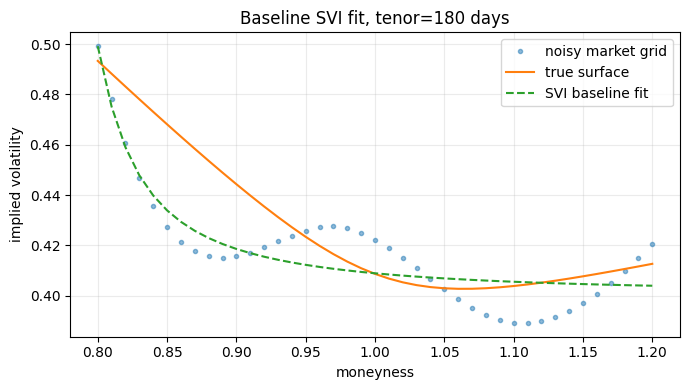

In [34]:
example_idx = EVAL_INDICES[0]
example_tenor = 5  # 6-month tenor
noisy = X_noisy[example_idx, :, :, 0]
clean = X_clean[example_idx, :, :, 0]
recon = baseline_recons[example_idx]

plt.figure(figsize=(7, 4))
plt.plot(
    MONEYNESS_GRID,
    noisy[example_tenor],
    "o",
    ms=3,
    alpha=0.5,
    label="noisy market grid",
)
plt.plot(MONEYNESS_GRID, clean[example_tenor], "-", label="true surface")
plt.plot(MONEYNESS_GRID, recon[example_tenor], "--", label="SVI baseline fit")
plt.xlabel("moneyness")
plt.ylabel("implied volatility")
plt.title(f"Baseline SVI fit, tenor={MATURITY_DAYS[example_tenor]:.0f} days")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("documents/ProgressReport/figures/baseline_svi_fit.png", dpi=200)
plt.show()

## 4. Primary Model: Convolutional Autoencoder

Encoder: 3 conv layers -> latent vector. Decoder: FC -> transposed convs -> Softplus output
(non-negative implied vol).

In [35]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=32, input_shape=(N_MATURITY, N_MONEYNESS)):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        # infer encoder output shape rather than hardcoding it
        with torch.no_grad():
            dummy = torch.zeros(1, 1, *input_shape)
            self._enc_shape = tuple(self.encoder(dummy).shape[1:])
        flat_dim = int(np.prod(self._enc_shape))
        self.enc_fc = nn.Linear(flat_dim, latent_dim)
        self.dec_fc = nn.Linear(latent_dim, flat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                32, 16, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                16, 8, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=3, stride=1, padding=1),
        )
        self.output_activation = nn.Softplus()
        self._target_shape = input_shape

    def forward(self, x):
        z = self.encoder(x).flatten(1)
        z = self.enc_fc(z)
        out = self.dec_fc(z).view(-1, *self._enc_shape)
        out = self.decoder(out)
        # crop/pad back to target shape in case stride doesn't divide evenly
        out = out[..., : self._target_shape[0], : self._target_shape[1]]
        return self.output_activation(out)


model = ConvAutoencoder(latent_dim=32).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {n_params:,}")
print(f"encoder output shape (per sample): {model._enc_shape}")

with torch.no_grad():
    test_out = model(X_noisy_t[:2].to(device))
print(
    f"sanity check output shape: {tuple(test_out.shape)} (expect (2, 1, {N_MATURITY}, {N_MONEYNESS}))"
)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (enc_fc): Linear(in_features=1056, out_features=32, bias=True)
  (dec_fc): Linear(in_features=32, out_features=1056, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(8, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (output_activation): Softplus(beta=1.0, threshold=20.0)
)

Total trainable parameters: 80,417
encoder output shape (per sample): (32, 3, 11)
sanity check output shape: (2, 1, 12, 41) (expect (2, 1, 12, 41)

### 4.1 Loss: reconstruction fidelity + soft no-arbitrage penalties

MSE is fidelity to the noisy input, not the clean surface. Two penalties supply the
denoising pressure:

- **Calendar arbitrage**: total variance must be non-decreasing in maturity.
- **Butterfly arbitrage**: the Black-Scholes call price must be convex in strike
  (non-negative risk-neutral density).

In [36]:
MATURITY_YEARS_T = torch.tensor(
    MATURITY_YEARS, dtype=torch.float32, device=device
).view(1, 1, -1, 1)
MONEYNESS_GRID_T = torch.tensor(
    MONEYNESS_GRID, dtype=torch.float32, device=device
).view(1, 1, 1, -1)
LOG_MONEYNESS_T = torch.log(MONEYNESS_GRID_T)
_SQRT_2 = float(np.sqrt(2.0))


def calendar_arbitrage_penalty(iv_pred):
    total_var = iv_pred**2 * MATURITY_YEARS_T
    diffs = total_var[:, :, :-1, :] - total_var[:, :, 1:, :]  # should be <= 0
    violation = torch.clamp(diffs, min=0)
    return (violation**2).mean()


def bs_call_price(iv, tau):
    """Black-Scholes call price with S=1, r=0, q=0, so K = moneyness."""
    sqrt_tau = torch.sqrt(tau)
    d1 = (-LOG_MONEYNESS_T + 0.5 * iv**2 * tau) / (iv * sqrt_tau + 1e-8)
    d2 = d1 - iv * sqrt_tau
    norm_cdf = lambda x: 0.5 * (1.0 + torch.erf(x / _SQRT_2))
    return norm_cdf(d1) - MONEYNESS_GRID_T * norm_cdf(d2)


def butterfly_arbitrage_penalty(iv_pred):
    """Penalizes non-convexity of call price in strike."""
    call_price = bs_call_price(iv_pred, MATURITY_YEARS_T)
    second_diff = (
        call_price[..., :-2] - 2 * call_price[..., 1:-1] + call_price[..., 2:]
    )  # should be >= 0
    violation = torch.clamp(-second_diff, min=0)
    return (violation**2).mean()


def loss_fn(pred, target, calendar_weight=0.5, butterfly_weight=0.5):
    mse = nn.functional.mse_loss(pred, target)
    cal_penalty = calendar_arbitrage_penalty(pred)
    fly_penalty = butterfly_arbitrage_penalty(pred)
    total = mse + calendar_weight * cal_penalty + butterfly_weight * fly_penalty
    return total, mse.item(), cal_penalty.item(), fly_penalty.item()

### 4.2 Training

In [37]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
N_EPOCHS = 60
CALENDAR_WEIGHT = 1.0
BUTTERFLY_WEIGHT = 1.0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_mse": [],
    "val_mse": [],
    "train_cal": [],
    "val_cal": [],
    "train_fly": [],
    "val_fly": [],
    "val_clean_mse": [],  # monitoring only, not trained on
}

for epoch in range(N_EPOCHS):
    model.train()
    train_losses, train_mses, train_cals, train_flys = [], [], [], []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss, mse, cal, fly = loss_fn(pred, xb, CALENDAR_WEIGHT, BUTTERFLY_WEIGHT)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        train_mses.append(mse)
        train_cals.append(cal)
        train_flys.append(fly)

    model.eval()
    val_losses, val_mses, val_cals, val_flys, val_clean_mses = [], [], [], [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss, mse, cal, fly = loss_fn(pred, xb, CALENDAR_WEIGHT, BUTTERFLY_WEIGHT)
            val_losses.append(loss.item())
            val_mses.append(mse)
            val_cals.append(cal)
            val_flys.append(fly)
            val_clean_mses.append(nn.functional.mse_loss(pred, yb).item())

    history["train_loss"].append(float(np.mean(train_losses)))
    history["val_loss"].append(float(np.mean(val_losses)))
    history["train_mse"].append(float(np.mean(train_mses)))
    history["val_mse"].append(float(np.mean(val_mses)))
    history["train_cal"].append(float(np.mean(train_cals)))
    history["val_cal"].append(float(np.mean(val_cals)))
    history["train_fly"].append(float(np.mean(train_flys)))
    history["val_fly"].append(float(np.mean(val_flys)))
    history["val_clean_mse"].append(float(np.mean(val_clean_mses)))

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"epoch {epoch+1:>3}/{N_EPOCHS}  train_loss={history['train_loss'][-1]:.6f}  "
            f"val_loss={history['val_loss'][-1]:.6f}  val_mse(vs noisy)={history['val_mse'][-1]:.6f}  "
            f"val_cal_pen={history['val_cal'][-1]:.6f}  val_fly_pen={history['val_fly'][-1]:.6f}  "
            f"val_mse(vs clean, monitoring only)={history['val_clean_mse'][-1]:.6f}"
        )

epoch   1/60  train_loss=0.066308  val_loss=0.017393  val_mse(vs noisy)=0.016671  val_cal_pen=0.000135  val_fly_pen=0.000587  val_mse(vs clean, monitoring only)=0.012256
epoch   5/60  train_loss=0.005945  val_loss=0.005889  val_mse(vs noisy)=0.005876  val_cal_pen=0.000003  val_fly_pen=0.000009  val_mse(vs clean, monitoring only)=0.001832
epoch  10/60  train_loss=0.004373  val_loss=0.004571  val_mse(vs noisy)=0.004561  val_cal_pen=0.000003  val_fly_pen=0.000007  val_mse(vs clean, monitoring only)=0.000803
epoch  15/60  train_loss=0.003537  val_loss=0.004039  val_mse(vs noisy)=0.004030  val_cal_pen=0.000006  val_fly_pen=0.000004  val_mse(vs clean, monitoring only)=0.000617
epoch  20/60  train_loss=0.003329  val_loss=0.003666  val_mse(vs noisy)=0.003627  val_cal_pen=0.000036  val_fly_pen=0.000003  val_mse(vs clean, monitoring only)=0.000650
epoch  25/60  train_loss=0.002996  val_loss=0.003651  val_mse(vs noisy)=0.003645  val_cal_pen=0.000004  val_fly_pen=0.000002  val_mse(vs clean, monito

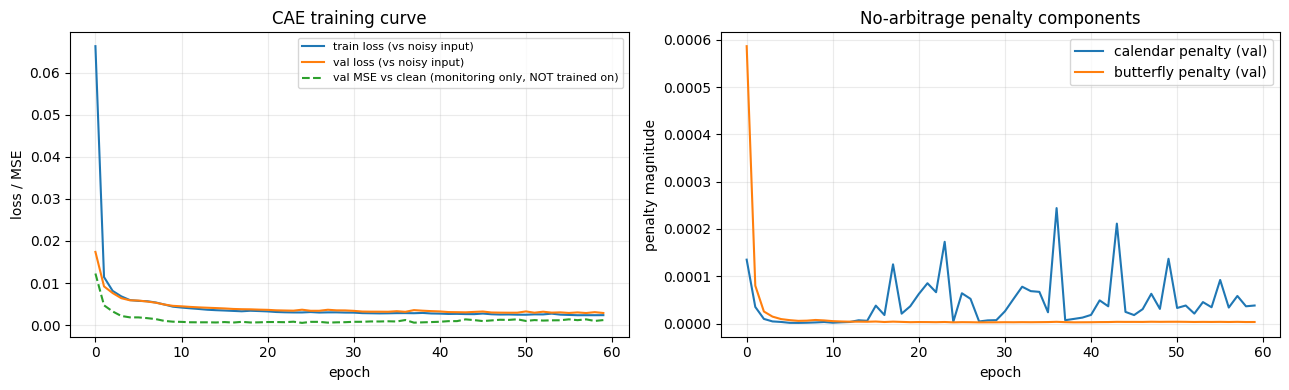

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="train loss (vs noisy input)")
axes[0].plot(history["val_loss"], label="val loss (vs noisy input)")
axes[0].plot(
    history["val_clean_mse"],
    "--",
    label="val MSE vs clean (monitoring only, NOT trained on)",
)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss / MSE")
axes[0].set_title("CAE training curve")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(history["val_cal"], label="calendar penalty (val)")
axes[1].plot(history["val_fly"], label="butterfly penalty (val)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("penalty magnitude")
axes[1].set_title("No-arbitrage penalty components")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig("documents/ProgressReport/figures/training_curves.png", dpi=200)
plt.show()

## 5. Results: Quantitative Comparison and Qualitative Reconstructions

CAE test MSE over 100 samples (same subset as baseline):
  mean:   0.000731
  median: 0.000233
  std:    0.001576


,model,mean_test_mse,median_test_mse,std_test_mse
0,SVI baseline,0.000935,0.000479,0.001522
1,Convolutional Autoencoder,0.000731,0.000233,0.001576


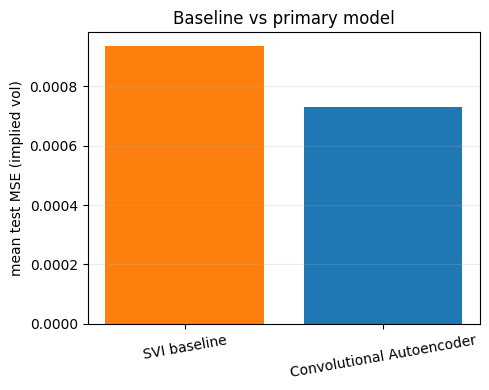

In [39]:
model.eval()
eval_noisy = X_noisy_t[EVAL_INDICES].to(device)
eval_clean = X_clean_t[EVAL_INDICES].to(device)
with torch.no_grad():
    eval_pred = model(eval_noisy)

cae_mses = ((eval_pred - eval_clean) ** 2).mean(dim=[1, 2, 3]).cpu().numpy()
print(f"CAE test MSE over {len(EVAL_INDICES)} samples (same subset as baseline):")
print(f"  mean:   {cae_mses.mean():.6f}")
print(f"  median: {np.median(cae_mses):.6f}")
print(f"  std:    {cae_mses.std():.6f}")

comparison_df = pd.DataFrame(
    {
        "model": ["SVI baseline", "Convolutional Autoencoder"],
        "mean_test_mse": [baseline_mses.mean(), cae_mses.mean()],
        "median_test_mse": [np.median(baseline_mses), np.median(cae_mses)],
        "std_test_mse": [baseline_mses.std(), cae_mses.std()],
    }
)
display(comparison_df)

plt.figure(figsize=(5, 4))
plt.bar(comparison_df["model"], comparison_df["mean_test_mse"], color=["C1", "C0"])
plt.ylabel("mean test MSE (implied vol)")
plt.title("Baseline vs primary model")
plt.grid(alpha=0.25, axis="y")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

Qualitative: noisy input vs CAE reconstruction vs ground truth, on testing split.

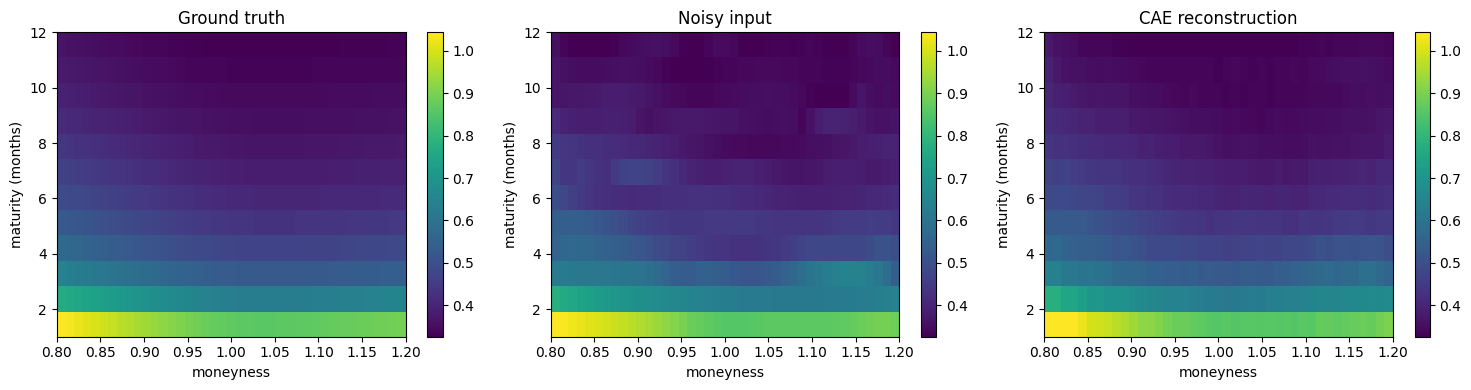

sample 2:  baseline MSE=0.000264  CAE MSE=0.000122


In [41]:
sample_i = 0
sample_idx = EVAL_INDICES[sample_i]
noisy_np = X_noisy[sample_idx, :, :, 0]
clean_np = X_clean[sample_idx, :, :, 0]
pred_np = eval_pred[sample_i, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ["Ground truth", "Noisy input", "CAE reconstruction"]
data = [clean_np, noisy_np, pred_np]
vmin, vmax = clean_np.min(), clean_np.max()
for ax, title, d in zip(axes, titles, data):
    im = ax.imshow(
        d,
        aspect="auto",
        origin="lower",
        extent=[MONEYNESS_GRID[0], MONEYNESS_GRID[-1], 1, 12],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("moneyness")
    ax.set_ylabel("maturity (months)")
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("documents/ProgressReport/figures/cae_reconstruction.png", dpi=200)
plt.show()

print(
    f"sample {sample_idx}:  baseline MSE={baseline_mses[EVAL_INDICES.index(sample_idx)]:.6f}  "
    f"CAE MSE={cae_mses[sample_i]:.6f}"
)

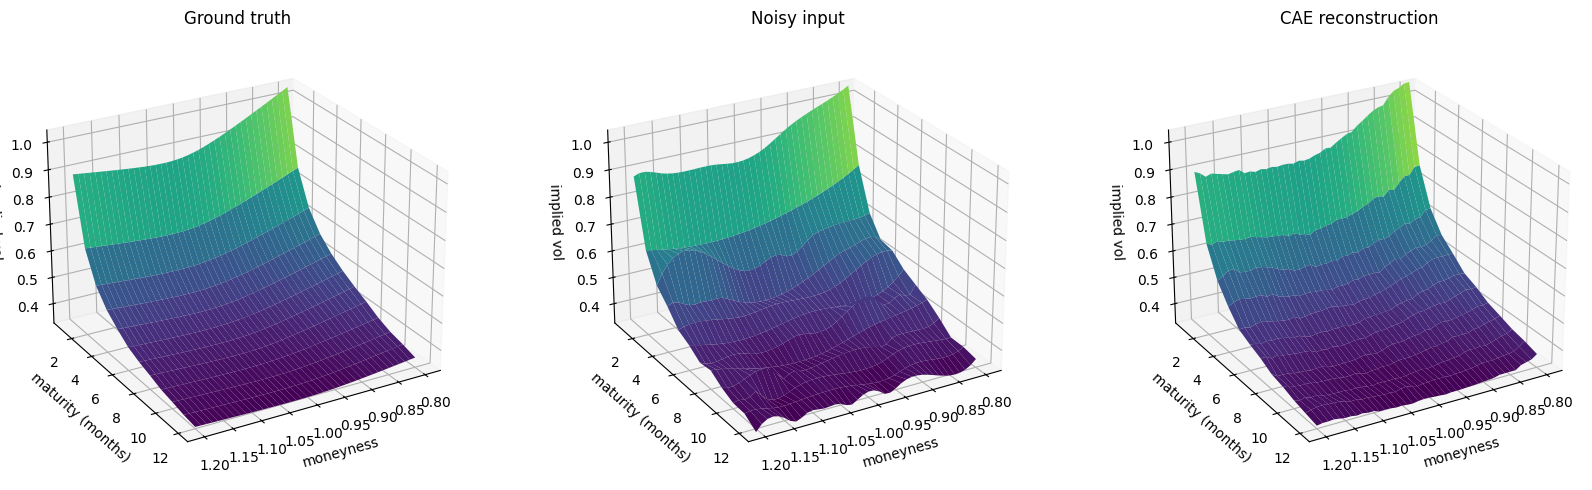

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(17, 5))
titles_3d = ["Ground truth", "Noisy input", "CAE reconstruction"]
data_3d = [clean_np, noisy_np, pred_np]
MM, TT = np.meshgrid(MONEYNESS_GRID, np.arange(1, N_MATURITY + 1))

for i, (title, d) in enumerate(zip(titles_3d, data_3d)):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    ax.plot_surface(
        MM, TT, d, cmap="viridis", vmin=vmin, vmax=vmax, linewidth=0, antialiased=True
    )
    ax.set_title(title)
    ax.set_xlabel("moneyness")
    ax.set_ylabel("maturity (months)")
    ax.set_zlabel("implied vol")
    ax.set_zlim(vmin, vmax)
    ax.view_init(elev=25, azim=60)

plt.tight_layout()
plt.show()

### 5.1 Arbitrage diagnostics: baseline vs. primary model

In [43]:
from scipy.stats import norm as _norm


def bs_call_price_np(iv_row, tau):
    """Numpy Black-Scholes call price for one tenor's IV row (S=1, r=0, K=moneyness)."""
    sqrt_tau = np.sqrt(tau)
    d1 = (-LOG_MONEYNESS + 0.5 * iv_row**2 * tau) / (iv_row * sqrt_tau + 1e-8)
    d2 = d1 - iv_row * sqrt_tau
    return _norm.cdf(d1) - MONEYNESS_GRID * _norm.cdf(d2)


def arbitrage_diagnostics(surface):
    """Returns violation counts and magnitudes for both arbitrage types."""
    total_var = surface**2 * MATURITY_YEARS[:, None]
    cal_diff = total_var[:-1] - total_var[1:]
    cal_viol_mask = cal_diff > 1e-8
    n_cal = int(cal_viol_mask.sum())
    mag_cal = float(cal_diff[cal_viol_mask].sum())

    n_fly = 0
    mag_fly = 0.0
    for i, tau in enumerate(MATURITY_YEARS):
        call_price = bs_call_price_np(surface[i], tau)
        second_diff = call_price[:-2] - 2 * call_price[1:-1] + call_price[2:]
        fly_viol_mask = second_diff < -1e-8
        n_fly += int(fly_viol_mask.sum())
        mag_fly += float(-second_diff[fly_viol_mask].sum())

    return n_cal, mag_cal, n_fly, mag_fly


baseline_cal, baseline_cal_mag, baseline_fly, baseline_fly_mag = 0, 0.0, 0, 0.0
cae_cal, cae_cal_mag, cae_fly, cae_fly_mag = 0, 0.0, 0, 0.0
for i, idx in enumerate(EVAL_INDICES):
    c, cm, f, fm = arbitrage_diagnostics(baseline_recons[idx])
    baseline_cal += c
    baseline_cal_mag += cm
    baseline_fly += f
    baseline_fly_mag += fm
    c, cm, f, fm = arbitrage_diagnostics(eval_pred[i, 0].detach().cpu().numpy())
    cae_cal += c
    cae_cal_mag += cm
    cae_fly += f
    cae_fly_mag += fm

n_cal_checks = len(EVAL_INDICES) * (N_MATURITY - 1) * N_MONEYNESS
n_fly_checks = len(EVAL_INDICES) * N_MATURITY * (N_MONEYNESS - 2)

arb_df = pd.DataFrame(
    {
        "model": ["SVI baseline", "Convolutional Autoencoder"],
        "calendar_violation_rate": [
            baseline_cal / n_cal_checks,
            cae_cal / n_cal_checks,
        ],
        "calendar_avg_violation_magnitude": [
            baseline_cal_mag / max(baseline_cal, 1),
            cae_cal_mag / max(cae_cal, 1),
        ],
        "butterfly_violation_rate": [
            baseline_fly / n_fly_checks,
            cae_fly / n_fly_checks,
        ],
        "butterfly_avg_violation_magnitude": [
            baseline_fly_mag / max(baseline_fly, 1),
            cae_fly_mag / max(cae_fly, 1),
        ],
    }
)
display(arb_df)

,model,calendar_violation_rate,calendar_avg_violation_magnitude,butterfly_violation_rate,butterfly_avg_violation_magnitude
0,SVI baseline,0.329379,0.008174,0.015107,0.000134
1,Convolutional Autoencoder,0.274412,0.003529,0.455385,0.001489
